In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

smh = pd.read_csv('Student Mental health.csv')
smh.head()


Saving Student Mental health.csv to Student Mental health.csv


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [2]:
smh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [3]:
smh.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
96,False
97,False
98,False
99,False


In [7]:
smh.isnull().sum()

,0
Timestamp,0
Choose your gender,0
Age,0
What is your course?,0
Your current year of Study,0
What is your CGPA?,0
Marital status,0
Do you have Depression?,0
Do you have Anxiety?,0
Do you have Panic attack?,0


In [8]:
smh['Age'].unique()

array([18.  , 21.  , 19.  , 22.  , 23.  , 20.  , 24.  , 20.53])

In [10]:
mean_age = smh['Age'].mean()
smh['Age'] = smh['Age'].fillna(mean_age)
smh['Age'].unique()



array([18.  , 21.  , 19.  , 22.  , 23.  , 20.  , 24.  , 20.53])

In [14]:

smh.rename(columns={'Choose your gender': 'gender'}, inplace=True)
smh['gender'].unique()

array(['Female', 'Male'], dtype=object)

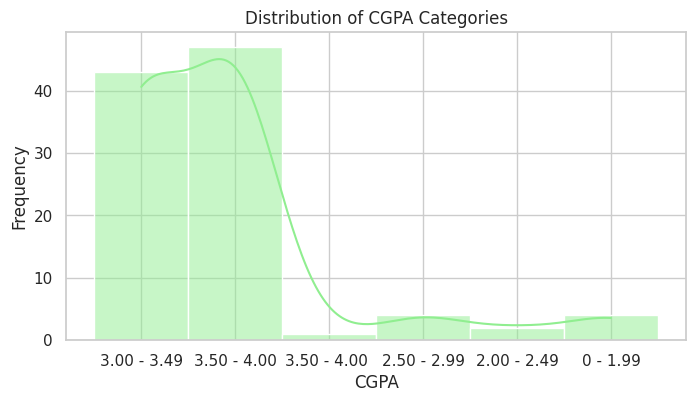

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))

sns.histplot(smh['What is your CGPA?'], kde=True, color='lightgreen', bins=10)
plt.title('Distribution of CGPA Categories')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

plt.show()


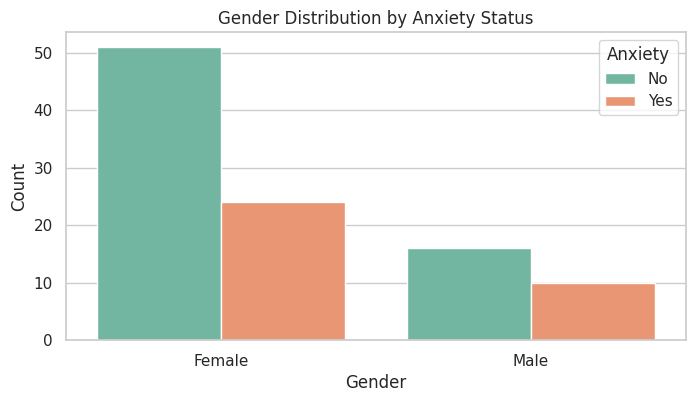

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.countplot(x='gender', hue='Do you have Anxiety?', data=smh, palette='Set2')
plt.title('Gender Distribution by Anxiety Status')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Anxiety', labels=['No', 'Yes'])
plt.show()




 converting panic attack responses to numeric (e.g., Yes=1, No=0).

In [25]:
smh['Panic Attack Numeric'] = smh['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})
smh['Panic Attack Numeric'].unique()

array([1, 0])

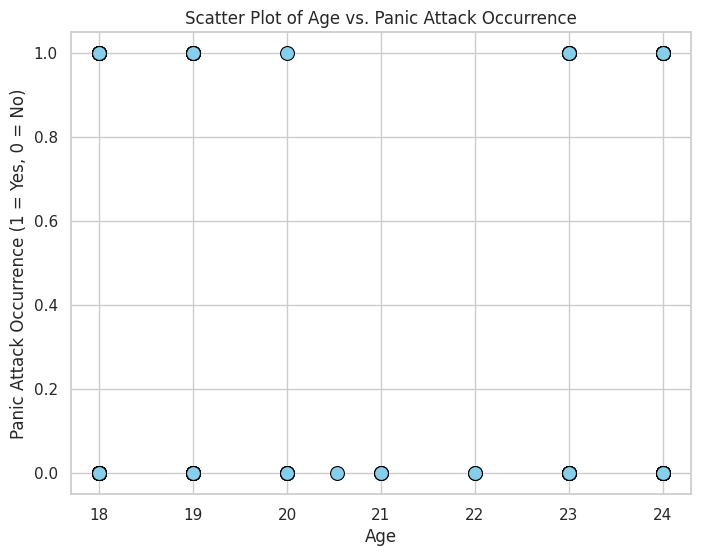

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Panic Attack Numeric', data=smh, color='skyblue', edgecolor='black', s=100)
plt.title('Scatter Plot of Age vs. Panic Attack Occurrence')
plt.xlabel('Age')
plt.ylabel('Panic Attack Occurrence (1 = Yes, 0 = No)')

plt.show()




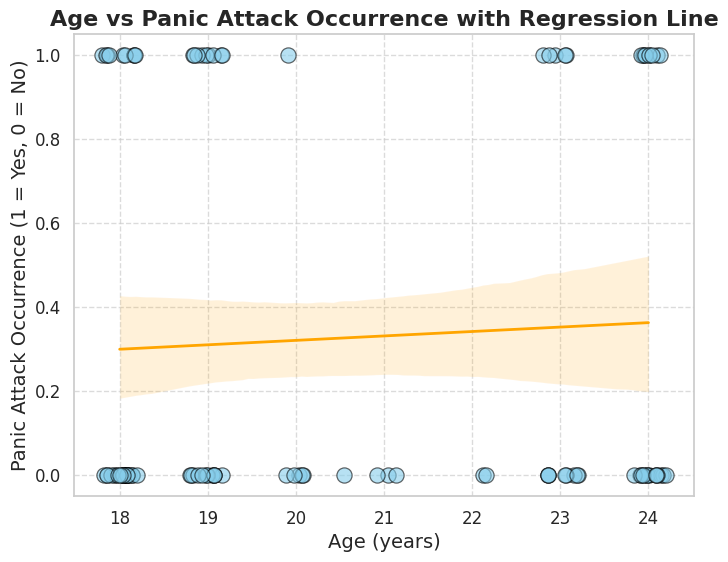

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


jitter_strength = 0.2

smh['Age Jittered'] = smh['Age'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(smh))
plt.figure(figsize=(8, 6))

sns.scatterplot(x='Age Jittered', y='Panic Attack Numeric', data=smh, color='skyblue', edgecolor='black',
                s=120, alpha=0.6)

sns.regplot(x='Age', y='Panic Attack Numeric', data=smh, scatter=False, color='orange', line_kws={'linewidth': 2})
plt.grid(True, linestyle='--', alpha=0.7)

plt.title('Age vs Panic Attack Occurrence with Regression Line', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=14)
plt.ylabel('Panic Attack Occurrence (1 = Yes, 0 = No)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()




<Figure size 1200x800 with 0 Axes>

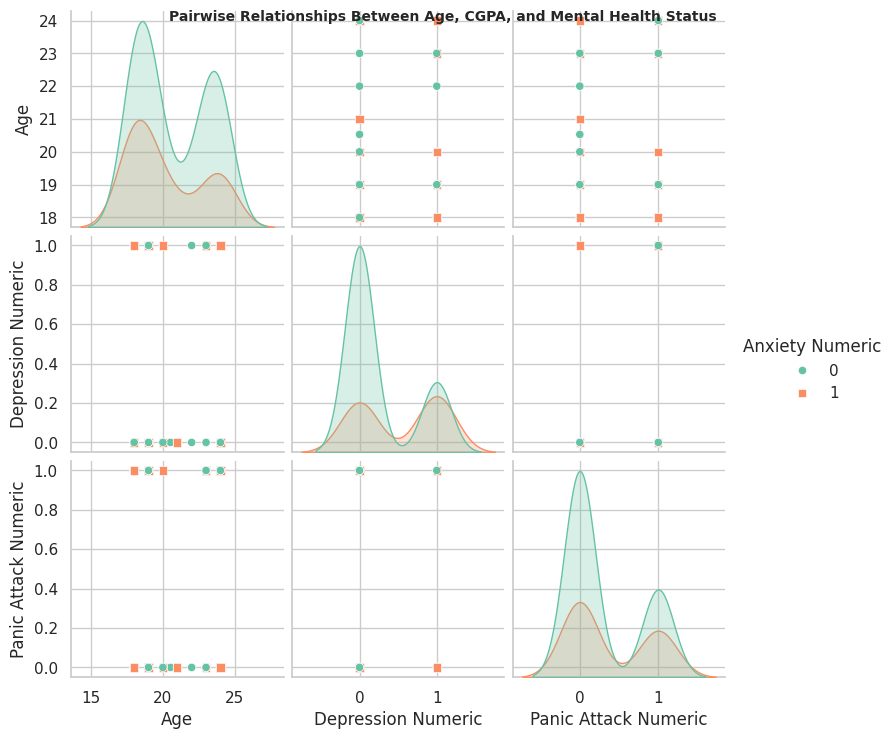

In [42]:

smh['Depression Numeric'] = smh['Do you have Depression?'].map({'Yes': 1, 'No': 0})
smh['Anxiety Numeric'] = smh['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})
columns_of_interest = ['Age', 'What is your CGPA?', 'Depression Numeric', 'Anxiety Numeric', 'Panic Attack Numeric']
plt.figure(figsize=(12, 8))

sns.pairplot(smh[columns_of_interest], hue='Anxiety Numeric', palette='Set2', markers=["o", "s"])
plt.suptitle('Pairwise Relationships Between Age, CGPA, and Mental Health Status', fontsize=10, fontweight='bold')

plt.show()


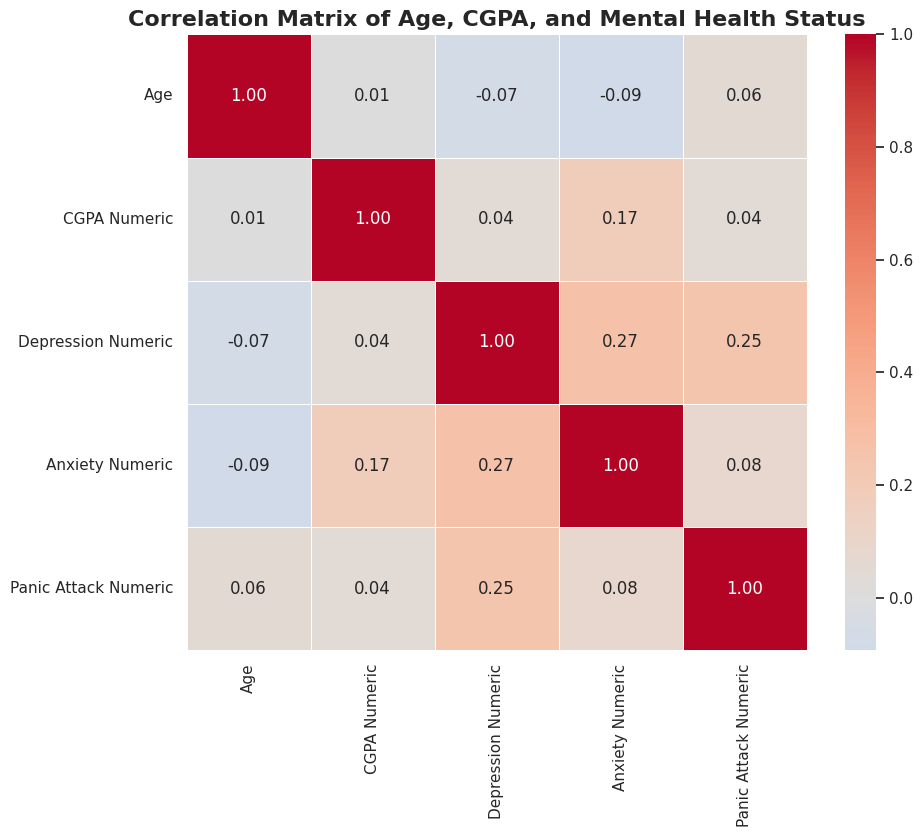

In [45]:

def convert_cgpa_to_numeric(cgpa_range):
    try:
        if '-' in cgpa_range:
            lower, upper = cgpa_range.split(' - ')
            return (float(lower) + float(upper)) / 2
        else:
            return float(cgpa_range)
    except Exception as e:
        print(f"Error converting CGPA value {cgpa_range}: {e}")
        return None

smh['CGPA Numeric'] = smh['What is your CGPA?'].apply(convert_cgpa_to_numeric)

columns_of_interest = ['Age', 'CGPA Numeric', 'Depression Numeric', 'Anxiety Numeric', 'Panic Attack Numeric']
correlation_matrix = smh[columns_of_interest].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Age, CGPA, and Mental Health Status', fontsize=16, fontweight='bold')
plt.show()


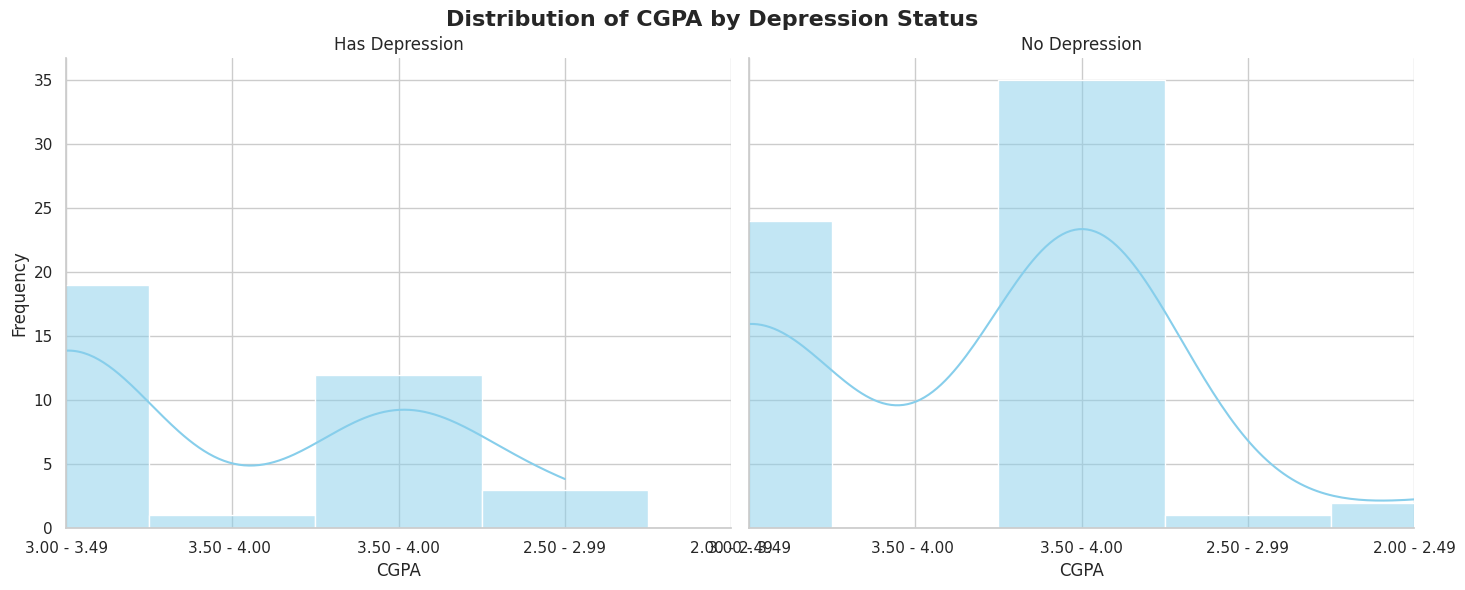

In [47]:
smh['Depression Status'] = smh['Do you have Depression?'].map({'Yes': 'Has Depression', 'No': 'No Depression'})
g = sns.FacetGrid(smh, col='Depression Status', height=6, aspect=1.2)
g.map(sns.histplot, 'What is your CGPA?', kde=True, color='skyblue')

g.set_axis_labels('CGPA', 'Frequency')
g.set_titles('{col_name}')
g.set(xlim=(0, 4))
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of CGPA by Depression Status', fontsize=16, fontweight='bold')

plt.show()